# Crisis Connect — Image Cleaning & Dataset Splitting
**CSC-233 AI Lab | Spring 2026**

### Classes: Earthquake | Flood | Fire | Traffic_Incidents

**Drive structure required:**
```
MyDrive/
  CrisisConnect/
    raw/
      Earthquake/
      Flood/
      Fire/
      Traffic_Incidents/
```
Run cells top to bottom. Do not skip any cell.

## Cell 1 — Install packages

In [2]:
!pip install imagehash Pillow tqdm split-folders -q
print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.0 MB/s eta 0:00:00
All packages installed.


## Cell 2 — Mount Drive and check raw counts

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os

CLASSES   = ['earthquake', 'flood', 'fire', 'traffic_incident']
EXTS      = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
RAW_DIR   = '/content/drive/MyDrive/crisis connect'
CLEAN_DIR = '/content/drive/MyDrive/crisis connect_clean'
SPLIT_DIR = '/content/drive/MyDrive/crisis connect_split'
for cls in CLASSES:
    os.makedirs(os.path.join(CLEAN_DIR, cls), exist_ok=True)

print()
print(f'  {"Class":<22} {"Images found":>14}')
print('  ' + '-' * 38)

raw_counts = {}
all_ok = True
for cls in CLASSES:
    path = os.path.join(RAW_DIR, cls)
    if os.path.exists(path):
        n = len([f for f in os.listdir(path) if f.lower().endswith(EXTS)])
        raw_counts[cls] = n
        flag = '' if n >= 50 else '  WARNING: LOW'
        print(f'  {cls:<22} {n:>14}{flag}')
    else:
        print(f'  {cls:<22}   FOLDER NOT FOUND')
        all_ok = False

if raw_counts:
    smallest = min(raw_counts.values())
    largest  = max(raw_counts.values())
    ratio    = largest / smallest if smallest > 0 else 999
    print()
    print(f'  Smallest class : {smallest} images')
    print(f'  Largest class  : {largest} images')
    print(f'  Imbalance ratio: {ratio:.1f}x')
    if ratio <= 2:
        print('  Balance        : GOOD')
    elif ratio <= 4:
        print('  Balance        : ACCEPTABLE — large classes will be capped')
    else:
        print('  Balance        : IMBALANCED — capping is critical')

print()
if all_ok:
    print('All 4 class folders found. Proceed to Cell 3.')
else:
    print('Fix missing folders before continuing.')

Mounted at /content/drive

  Class                    Images found
  --------------------------------------
  earthquake                        511
  flood                             612
  fire                              521
  traffic_incident                  485

  Smallest class : 485 images
  Largest class  : 612 images
  Imbalance ratio: 1.3x
  Balance        : GOOD

All 4 class folders found. Proceed to Cell 3.


## Cell 3 — Remove corrupt images

In [4]:
from PIL import Image
import os
from tqdm import tqdm

total_removed = 0
total_checked = 0

print('Scanning for corrupt images...')
print()
for cls in CLASSES:
    folder = os.path.join(RAW_DIR, cls)
    if not os.path.exists(folder):
        continue
    files   = [f for f in os.listdir(folder) if f.lower().endswith(EXTS)]
    removed = 0
    for fname in tqdm(files, desc=f'  {cls}'):
        fpath = os.path.join(folder, fname)
        total_checked += 1
        try:
            img = Image.open(fpath)
            img.verify()
        except Exception:
            os.remove(fpath)
            removed += 1
            total_removed += 1
    print(f'    {cls}: removed {removed} corrupt files')

print()
print(f'Total checked : {total_checked}')
print(f'Total removed : {total_removed}')

Scanning for corrupt images...



  earthquake: 100%|██████████| 511/511 [00:11<00:00, 45.60it/s]


    earthquake: removed 0 corrupt files


  flood: 100%|██████████| 612/612 [00:12<00:00, 48.49it/s] 


    flood: removed 0 corrupt files


  fire: 100%|██████████| 521/521 [00:08<00:00, 59.19it/s] 


    fire: removed 0 corrupt files


  traffic_incident: 100%|██████████| 485/485 [00:06<00:00, 72.62it/s] 

    traffic_incident: removed 0 corrupt files

Total checked : 2129
Total removed : 0


## Cell 4 — Remove duplicate images (perceptual hashing)

In [5]:
import imagehash
from PIL import Image
import os
from tqdm import tqdm

HASH_THRESHOLD = 5

print('Removing duplicate images...')
print(f'  {"Class":<22} {"Removed":>10} {"Remaining":>12}')
print('  ' + '-' * 46)

grand_removed = 0

for cls in CLASSES:
    folder = os.path.join(RAW_DIR, cls)
    if not os.path.exists(folder):
        continue
    files   = [f for f in os.listdir(folder) if f.lower().endswith(EXTS)]
    hashes  = {}
    removed = 0
    for fname in tqdm(files, desc=f'  {cls}', leave=False):
        fpath = os.path.join(folder, fname)
        try:
            img = Image.open(fpath).convert('RGB')
            h   = imagehash.phash(img)
            if any(abs(h - eh) <= HASH_THRESHOLD for eh in hashes):
                os.remove(fpath)
                removed += 1
            else:
                hashes[h] = fname
        except Exception:
            pass
    grand_removed += removed
    remaining = len([f for f in os.listdir(folder) if f.lower().endswith(EXTS)])
    print(f'  {cls:<22} {removed:>10} {remaining:>12}')

print('  ' + '-' * 46)
print(f'  Total duplicates removed: {grand_removed}')

Removing duplicate images...
  Class                     Removed    Remaining
  ----------------------------------------------


  earthquake                      0          511


  flood                           0          612


  fire                            0          521


  traffic_incident                0          485
  ----------------------------------------------
  Total duplicates removed: 0


## Cell 5 — Resize to 224x224 and save to clean folder

In [6]:
from PIL import Image
import os
from tqdm import tqdm

IMG_SIZE    = (224, 224)
total_saved = 0

print(f'Resizing all images to {IMG_SIZE} and copying to clean/ ...')
print()

for cls in CLASSES:
    src  = os.path.join(RAW_DIR,   cls)
    dest = os.path.join(CLEAN_DIR, cls)
    if not os.path.exists(src):
        continue
    files   = [f for f in os.listdir(src) if f.lower().endswith(EXTS)]
    saved   = 0
    skipped = 0
    for i, fname in enumerate(tqdm(files, desc=f'  {cls}')):
        try:
            img = Image.open(os.path.join(src, fname)).convert('RGB')
            img = img.resize(IMG_SIZE, Image.BILINEAR)
            img.save(os.path.join(dest, f'{cls.lower()}_{i:05d}.jpg'), 'JPEG', quality=90)
            saved += 1
        except Exception:
            skipped += 1
    total_saved += saved
    print(f'  {cls:<22}  saved: {saved}   skipped: {skipped}')

print()
print(f'Total clean images: {total_saved}')

Resizing all images to (224, 224) and copying to clean/ ...



  earthquake: 100%|██████████| 511/511 [02:28<00:00,  3.45it/s]


  earthquake              saved: 511   skipped: 0


  flood: 100%|██████████| 612/612 [02:31<00:00,  4.05it/s]


  flood                   saved: 612   skipped: 0


  fire: 100%|██████████| 521/521 [02:25<00:00,  3.58it/s]


  fire                    saved: 521   skipped: 0


  traffic_incident: 100%|██████████| 485/485 [02:26<00:00,  3.31it/s]

  traffic_incident        saved: 485   skipped: 0

Total clean images: 2129


## Cell 6 — Auto-balance classes
Caps all classes at the size of the **smallest class**.
If your smallest class has very few images, set CAP manually below.

In [7]:
import os, random
random.seed(42)

clean_counts = {}
for cls in CLASSES:
    folder = os.path.join(CLEAN_DIR, cls)
    if os.path.exists(folder):
        clean_counts[cls] = len([f for f in os.listdir(folder) if f.endswith('.jpg')])

smallest = min(clean_counts.values())
largest  = max(clean_counts.values())

print('Clean image counts before balancing:')
for cls, n in clean_counts.items():
    print(f'  {cls:<22} {n}')
print()
print(f'Smallest class : {smallest} images')
print(f'Largest class  : {largest} images')

# CAP = smallest so all classes are equal
# To override: change the line below to e.g. CAP = 300
CAP = smallest
print(f'Capping all classes at : {CAP} images')

if smallest < 80:
    print()
    print('WARNING: Smallest class has fewer than 80 images.')
    print('Add more images to improve model accuracy.')

print()
print(f'  {"Class":<22} {"Before":>8} {"After":>8} {"Action":>10}')
print('  ' + '-' * 52)

for cls in CLASSES:
    folder = os.path.join(CLEAN_DIR, cls)
    if not os.path.exists(folder):
        continue
    files  = [f for f in os.listdir(folder) if f.endswith('.jpg')]
    before = len(files)
    action = 'OK'
    if before > CAP:
        for f in random.sample(files, before - CAP):
            os.remove(os.path.join(folder, f))
        action = 'CAPPED'
    after = len([f for f in os.listdir(folder) if f.endswith('.jpg')])
    print(f'  {cls:<22} {before:>8} {after:>8} {action:>10}')

Clean image counts before balancing:
  earthquake             511
  flood                  612
  fire                   521
  traffic_incident       485

Smallest class : 485 images
Largest class  : 612 images
Capping all classes at : 485 images

  Class                    Before    After     Action
  ----------------------------------------------------
  earthquake                  511      485     CAPPED
  flood                       612      485     CAPPED
  fire                        521      485     CAPPED
  traffic_incident            485      485         OK


## Cell 7 — Split into train / val / test (70 / 15 / 15)

In [8]:
import splitfolders
print('Splitting 70 / 15 / 15 ...')
splitfolders.ratio(CLEAN_DIR, output=SPLIT_DIR, seed=42, ratio=(0.70, 0.15, 0.15), group_prefix=None)
print('Split complete.')

Splitting 70 / 15 / 15 ...


Copying files: 1940 files [06:15,  5.17 files/s]

Split complete.


## Cell 8 — Verify final counts

In [9]:
import os
print()
print('=' * 62)
print('  FINAL DATASET SUMMARY — Crisis Connect')
print('=' * 62)
print(f'  {"Class":<22} {"Train":>7} {"Val":>7} {"Test":>7} {"Total":>8}')
print('  ' + '-' * 55)
gt = gt_train = gt_val = gt_test = 0
for cls in CLASSES:
    row = []
    for split in ['train', 'val', 'test']:
        path = os.path.join(SPLIT_DIR, split, cls)
        n = len(os.listdir(path)) if os.path.exists(path) else 0
        row.append(n)
    subtotal = sum(row)
    gt += subtotal; gt_train += row[0]; gt_val += row[1]; gt_test += row[2]
    print(f'  {cls:<22} {row[0]:>7} {row[1]:>7} {row[2]:>7} {subtotal:>8}')
print('  ' + '-' * 55)
print(f'  {"TOTAL":<22} {gt_train:>7} {gt_val:>7} {gt_test:>7} {gt:>8}')
print('=' * 62)
print()
print('  Saved to: CrisisConnect/dataset_split/')
print('  Maleeha  -> train + val  (Phase 2 ResNet-50)')
print('  Ezzah    -> text_descriptions.csv (Phase 3b NLP)')
print('  Imman    -> text_descriptions.csv (Phase 3a audio)')


  FINAL DATASET SUMMARY — Crisis Connect
  Class                    Train     Val    Test    Total
  -------------------------------------------------------
  earthquake                 397     104     122      623
  flood                      482     135     130      747
  fire                       438     124     120      682
  traffic_incident           339      72      74      485
  -------------------------------------------------------
  TOTAL                     1656     435     446     2537

  Saved to: CrisisConnect/dataset_split/
  Maleeha  -> train + val  (Phase 2 ResNet-50)
  Ezzah    -> text_descriptions.csv (Phase 3b NLP)
  Imman    -> text_descriptions.csv (Phase 3a audio)


## Cell 9 — Visual sample grid (sanity check)

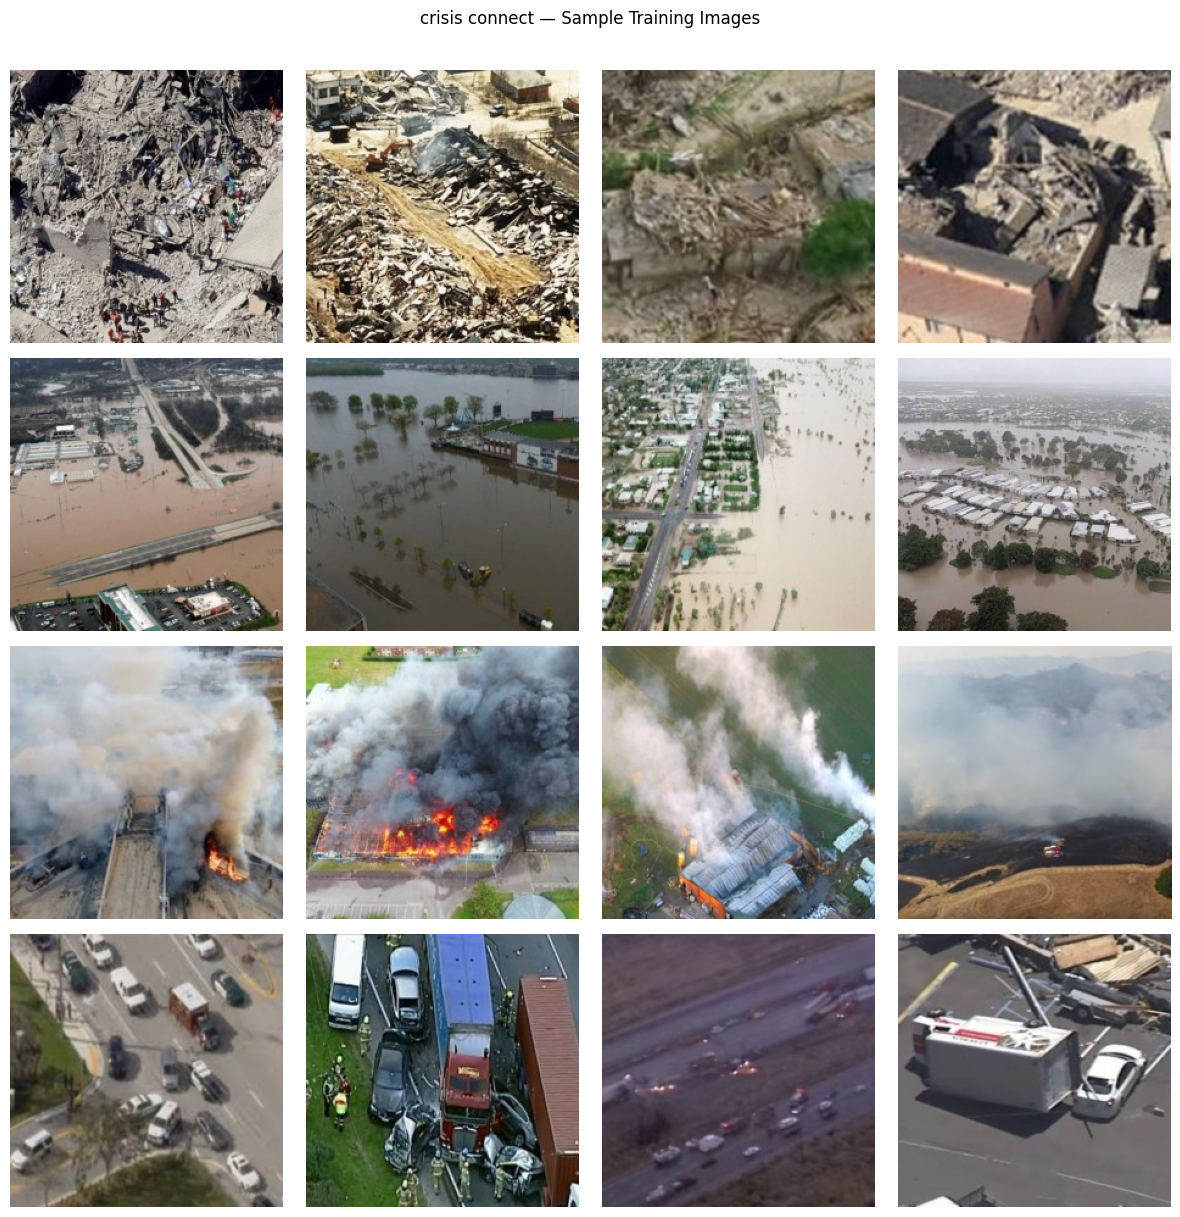

Sample grid saved: /content/drive/MyDrive/crisis connect/sample_grid.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os, random
random.seed(0)
COLS = 4
fig, axes = plt.subplots(len(CLASSES), COLS, figsize=(COLS * 3, len(CLASSES) * 3))
fig.suptitle('crisis connect — Sample Training Images', fontsize=12, y=1.01)
for row, cls in enumerate(CLASSES):
    folder = os.path.join(SPLIT_DIR, 'train', cls)
    imgs   = [f for f in os.listdir(folder) if f.endswith('.jpg')] if os.path.exists(folder) else []
    samples = random.sample(imgs, min(COLS, len(imgs)))
    for col in range(COLS):
        ax = axes[row][col]
        if col < len(samples):
            try:
                ax.imshow(mpimg.imread(os.path.join(folder, samples[col])))
            except:
                ax.text(0.5, 0.5, 'error', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cls, fontsize=9, fontweight='bold', rotation=0, labelpad=70, va='center')
plt.tight_layout()
out = '/content/drive/MyDrive/crisis connect/sample_grid.png'
plt.savefig(out, dpi=90, bbox_inches='tight')
plt.show()
print(f'Sample grid saved: {out}')